
# 01 - Exploratory Data Analysis (EDA) on precipitation dataset

**Goal:** Understand the precipitation dataset structure, detect data quality issues, and define initial hypotheses.

**Outputs:**
- Summary statistics and distributions
- Outliers/bad data
- Initial data quality observations

**Next:** Exploratory data analyis on stations data (historic Thresholds): `02_eda_stations.ipynb`


### Import Libraries

In [1]:
# Standard library imports
import time
import os
from pathlib import Path    

# Third-party imports
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

# Local application imports
from dlgoes.data.stations.clean import read_precipitation_dataset
from dlgoes.utils.config import load_config_ns
from dlgoes.utils.seed import set_seed
from dlgoes.utils.config import find_repo_root

repo_root = find_repo_root(Path.cwd())
cfg = load_config_ns(repo_root / 'configs' / 'base.yaml')
set_seed(cfg.seed)


### Read Data

In [2]:
# Read precipitation data from CSV files in the raw data directory

dfPrecipitacion = read_precipitation_dataset(cfg)
dfPrecipitacion.head(2)

,CODE,NOMBRE,FECHA,HORA,PRECIPITACION,FLAG
0,X0 4722A338\n1 4722A338\n2 ...,ACJANACO,03/04/2020,00:00:00,0.0,C0000001
1,X0 4722A338\n1 4722A338\n2 ...,ACJANACO,03/04/2020,01:00:00,0.0,C0000001


### Exploration data

In [3]:
# List of flags in the QC process by SENAMHI (Docs)
listaFases = [
    'ND',    'C0000001',    'M0000001',    'M0000001, M0110302' ,    'M0110302',
    'D0210301',    'D0210302',    'D0210303',    'D0210304',    'D0220301',
    'D0230301',    'D0230302',    'D0230303',    'D0230304',    'C0000002',
    'DIM00001',    'M0000002', 'NC'
]
dfFases = pd.DataFrame({'FLAG' : listaFases})
dfFases = dfFases.reset_index().set_index('FLAG')

In [4]:
print(list(dfPrecipitacion['FLAG'].unique()))

['C0000001', 'D0230301', 'D0230303', 'ND', 'C0000002', 'M0000001, M0110302', 'D0220301', 'M0110302', 'M0000001', 'M0000002', 'DIM00001']


In [5]:
# Check distribution of flags in the dataset
dfFlag = dfPrecipitacion.groupby(['FLAG'], dropna = False).size().reset_index(name='Cantidad')
dfFlag['Fase'] = dfFlag['FLAG'].map(dfFases['index'])
dfFlag = dfFlag.sort_values(by=['Fase'])
dfFlag['porc%'] = dfFlag['Cantidad'] / dfFlag['Cantidad'].sum() * 100

dfFlag

,FLAG,Cantidad,Fase,porc%
10,ND,462645,0,13.272817
0,C0000001,2877873,1,82.563264
6,M0000001,17,2,0.000488
7,"M0000001, M0110302",5646,3,0.161978
9,M0110302,554,4,0.015894
2,D0220301,24744,9,0.709880
3,D0230301,21440,10,0.615092
4,D0230303,25826,12,0.740922
1,C0000002,58364,14,1.674404
5,DIM00001,2,15,0.000057


### Analysis plots

In [6]:
# Group flags in NC, CX (Correct) , BX (Bad) and S (Suspect)
# X1 indicates phase 1 (Automatic) and X2 indicates phase 2 (Manual)
# Check the distribution of flags after grouping

_dfFlag = dfFlag.drop([6, 5], axis=0).copy() # Minority data (less than 1% of the data)
_dfFlag["FLAG"] = ["NC","C1","B1","B1","S","S","S","C2","B2"]

_dfFlag = (
    _dfFlag.groupby("FLAG", as_index=False)
           .sum(numeric_only=True)
)

_dfFlag["porc"] = _dfFlag["Cantidad"] / _dfFlag["Cantidad"].sum() * 100
_dfFlag["text"] = _dfFlag["porc"].map(lambda x: f"{x:1.2f}%")

fig = px.bar(_dfFlag, y="Cantidad", x="FLAG", text="text")
fig.update_layout(
    title={"text": "2020~2021 Precipitation Data", "x": 0.5, "xanchor": "center"},
    xaxis_title="FLAG",
    yaxis_title="Total",
    font={"size": 20},
    width=800, height=400
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

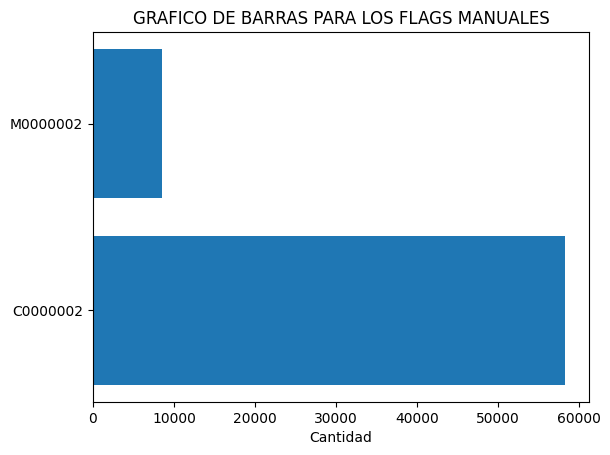

,FLAG,Cantidad,Fase,porc%,%ManualQC
1,C0000002,58364,14,1.674404,87.226316
8,M0000002,8547,16,0.245205,12.773684


In [7]:
# Check manually flagged data (C02 and B02/M02)
eliminarFG = [0,1,2,3,4,9,10,12,15]
dfFlagManual = dfFlag[~dfFlag['Fase'].isin(eliminarFG)]

fig, ax = plt.subplots()
ax.barh(dfFlagManual['FLAG'], dfFlagManual['Cantidad'])
plt.xlabel('Cantidad')
plt.title('GRAFICO DE BARRAS PARA LOS FLAGS MANUALES')
plt.show()

dfFlagManual['%ManualQC'] = dfFlagManual['Cantidad'] / dfFlagManual['Cantidad'].sum() * 100
dfFlagManual

Total       : 8547
Cantidad M01: 173


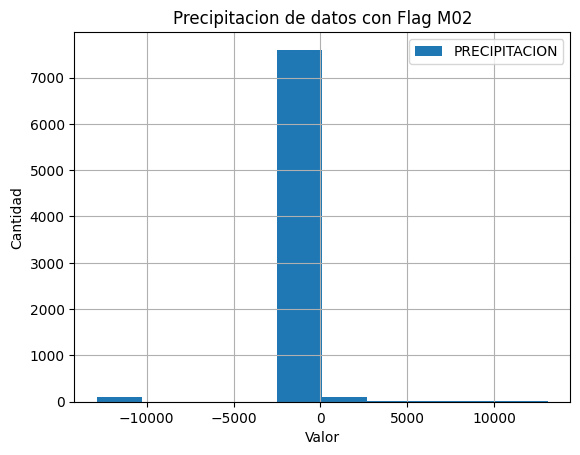

In [8]:
# Distribution of precipitation values for M0000002 (Manual Bad Data)

dfPrecipitacion[dfPrecipitacion['FLAG']=='M0000002']['PRECIPITACION'].hist(legend=True)
print(f"Total       : {len(dfPrecipitacion[dfPrecipitacion['FLAG']=='M0000002'])}")
print(f"Cantidad M01: {len(dfPrecipitacion[(dfPrecipitacion['FLAG']=='M0000002') & ((dfPrecipitacion['PRECIPITACION']>401) | (dfPrecipitacion['PRECIPITACION']<0))])}")
plt.xlabel('Valor')
plt.ylabel('Cantidad')
plt.title('Precipitacion de datos con Flag M02')
plt.show()


Total       : 58364
Cantidad M01: 64


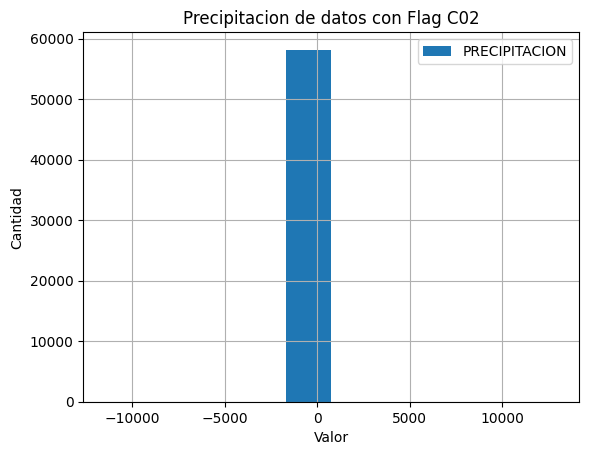

In [9]:
# Distribution of precipitation values for C0000002 (Manual Correct Data)

dfPrecipitacion[dfPrecipitacion['FLAG']=='C0000002']['PRECIPITACION'].hist(legend=True)
print(f"Total       : {len(dfPrecipitacion[dfPrecipitacion['FLAG']=='C0000002'])}")
print(f"Cantidad M01: {len(dfPrecipitacion[(dfPrecipitacion['FLAG']=='C0000002') & ((dfPrecipitacion['PRECIPITACION']>401) | (dfPrecipitacion['PRECIPITACION']<0))])}")
plt.xlabel('Valor')
plt.ylabel('Cantidad')
plt.title('Precipitacion de datos con Flag C02')
plt.show()


### Findings

- Variable `PRECIPITACION` shows incorrect values (negative values and outliers), even in data flagged as correct (C000002)
- Around 1.8% of the data has passed thougth manual QC (C02 and B02/M02)
- Among the manually flagged QC data, about 87% correspond to C02 (need a cleansing phase)

### Next Actions

- Analize the stations dataset
- Move the finalized cleaning rules to `src/.../cleaning.py`  once they are defined.s
